# Plotting EMS stuff

First of all, we are going to plot the data we have from the EMS. We have the following data:

In [1]:
from typing import Any

import numpy as np
from numpy import ndarray
import matplotlib.pyplot as plt
import torch
import matplotlib
import matplotlib.dates as mdates
import datetime

from utils_functions.funcionesEMS import *
from gymnasium import spaces
from environments.custom_env import Custom_env
from environments.EMS_env import EMS_env

In [2]:
timesteps = 144
time = range(timesteps)
x = np.array([datetime.datetime(2021, 1, 1, i, j) for i in range(24) for j in range(0, 60, 10)])
a = get_rad()
c = get_temperatura()
p_fv = solar_power(a, c)
b = get_demand()
%matplotlib inline

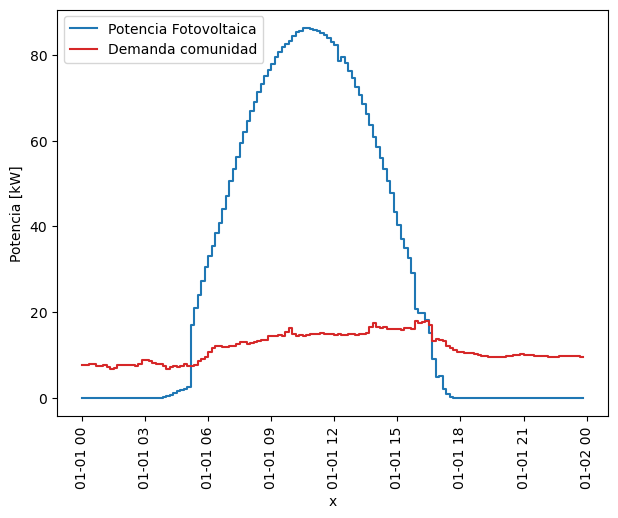

In [10]:
fig, ax = plt.subplots(dpi=100)
i = 0
# Plot the first curve and set its y label
delay = 0
color = 'tab:blue'
ax.set_xlabel('x')
ax.set_ylabel('Potencia [kW]')
ax.step(x, p_fv[timesteps*i+delay:timesteps*(i+1)+delay], color=color, label = 'Potencia Fotovoltaica')


# Create a second y-axis and plot the second curve on it
color = 'tab:red'
ax.step(x, c[timesteps*i+delay:timesteps*(i+1)+delay], color=color, label = 'Demanda comunidad')
ax.legend(loc='upper left')

fig.tight_layout()
plt.xticks(rotation=90)
plt.show()

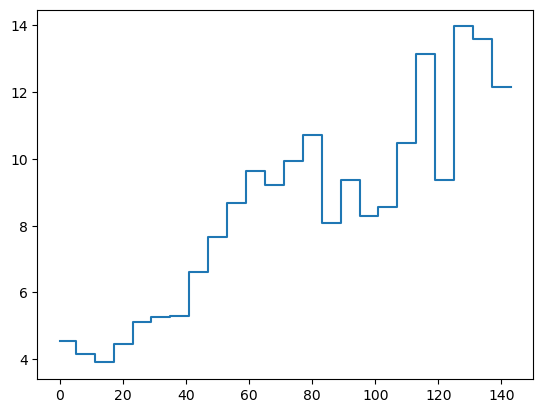

In [11]:
hourly_demand = np.genfromtxt("./Data/EMS/consumption.csv", delimiter=',')
demanda = np.zeros(24*6)
for idx, hour in enumerate(hourly_demand[0,:]):
    demanda[idx*6:(idx+1)*6] = hour
plt.step(range(24*6), demanda)

In [5]:
import pandas as pd

In [6]:
#path = 'training_results/ems/DQN_20240225_081124'
path = 'training_results/ems/DQN_20240307_065052'

training_results = pd.read_csv(path + '/training_results.csv')

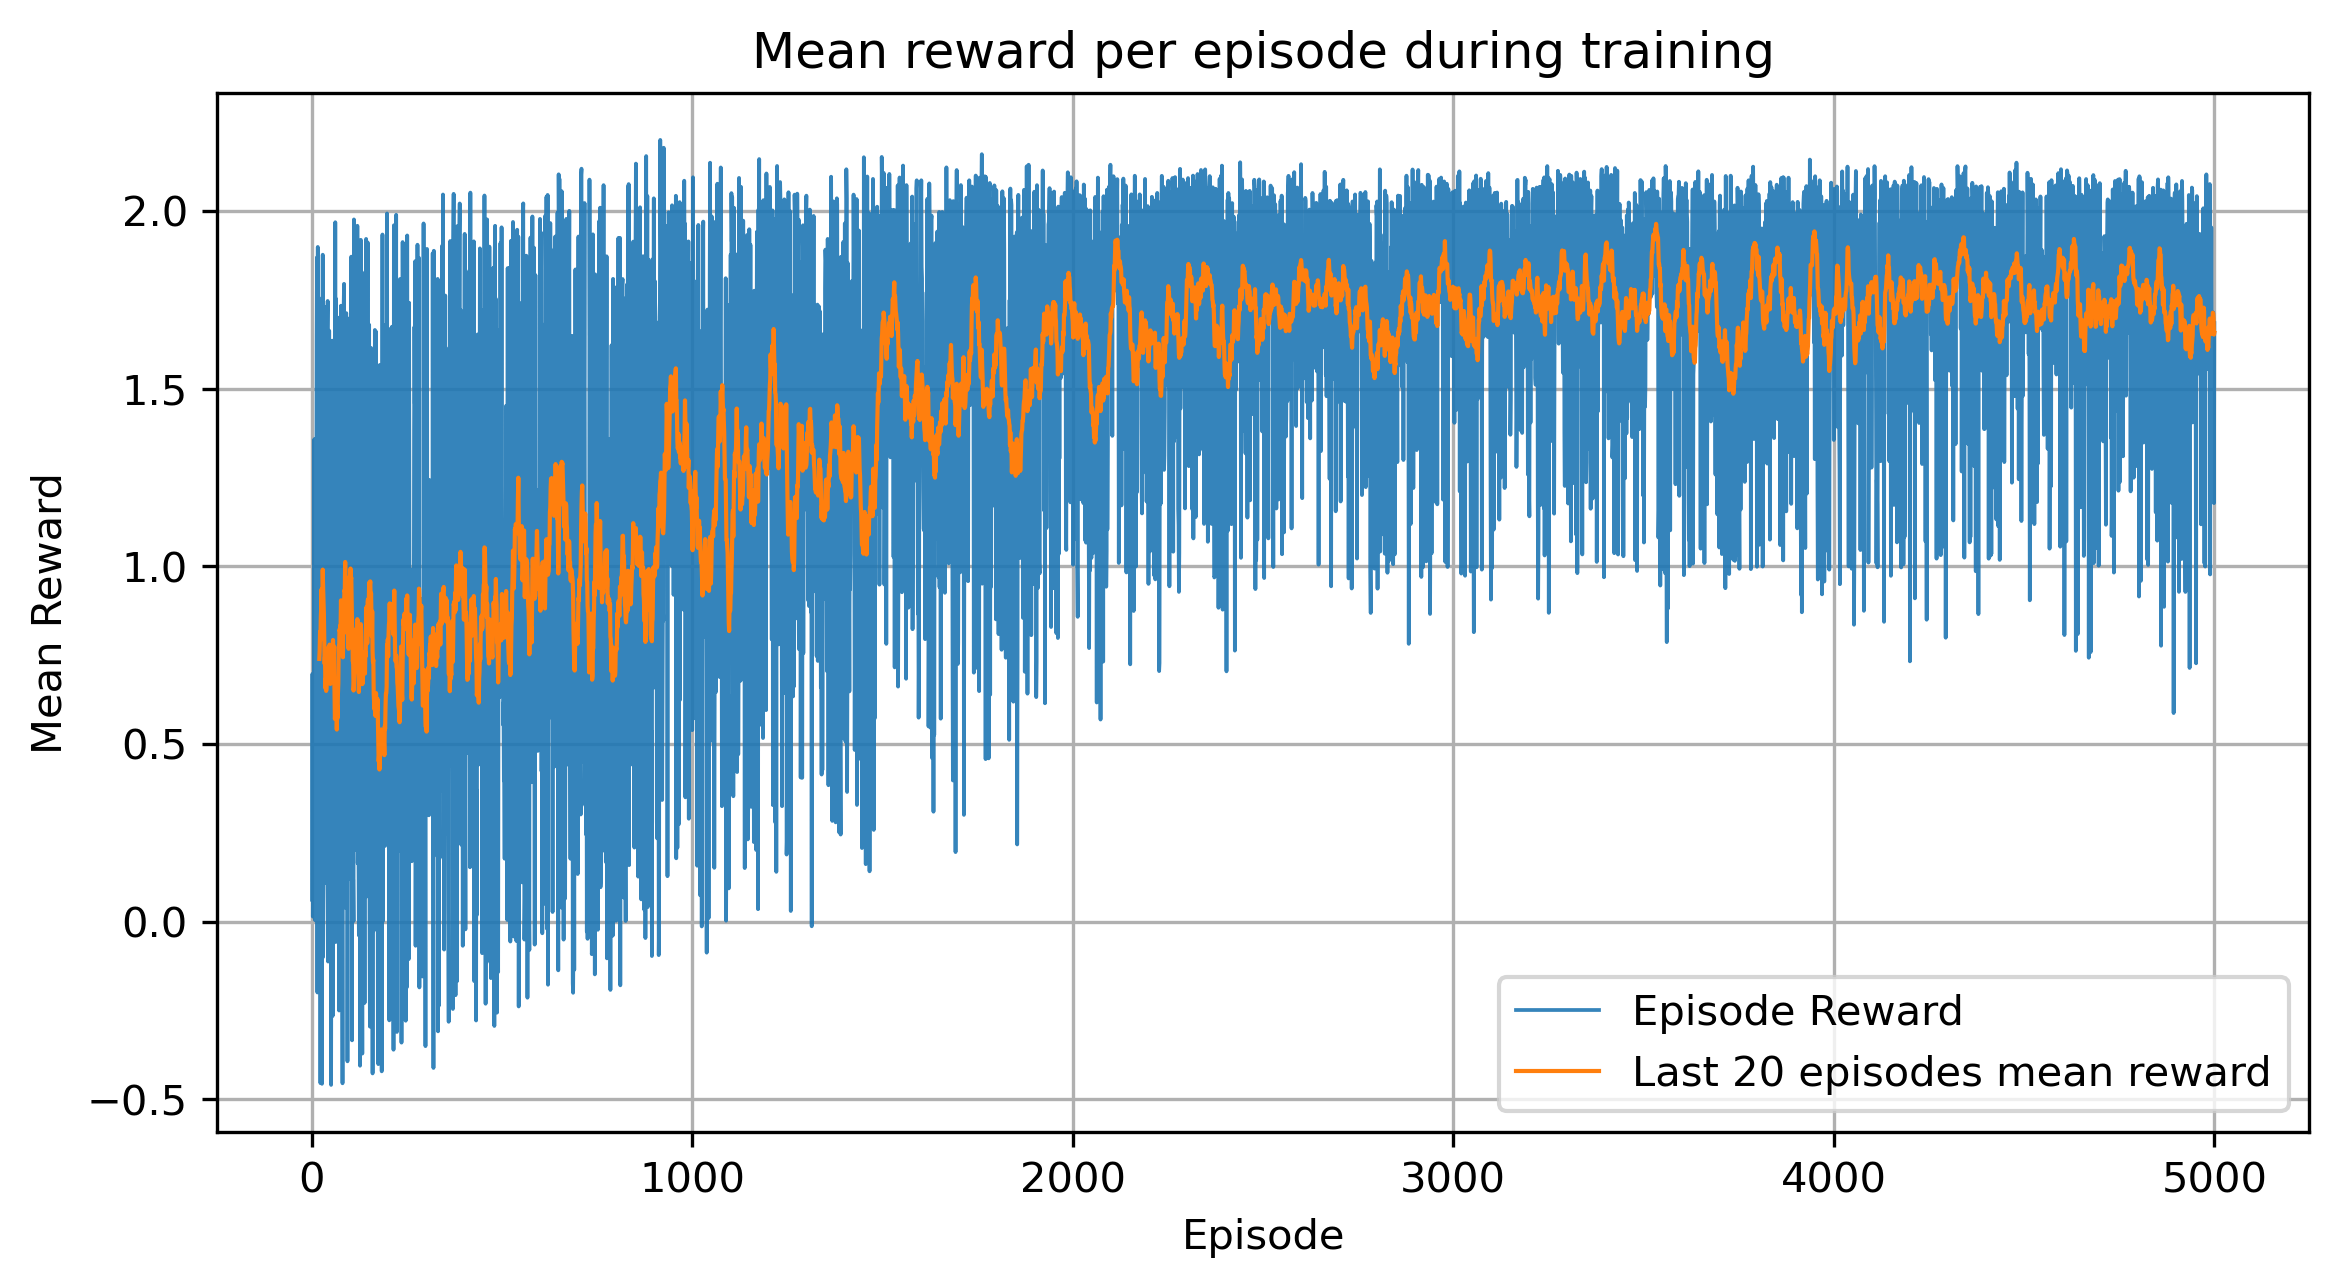

In [7]:
rwd = training_results["mean_episode_rewards"].to_numpy()
mean_rwd = np.convolve(rwd, np.ones(20)/20, mode='valid')
N = len(rwd)
fig = plt.figure(dpi=300)
fig.set_size_inches(9.0, 4.5)
plt.plot(range(1,N+1), rwd,  label="Episode Reward", alpha=0.9, linewidth = .9)
plt.plot(range(1+19, N+1),mean_rwd, label="Last 20 episodes mean reward", linewidth = 1)
plt.legend()
plt.xlabel("Episode")
plt.ylabel("Mean Reward")
plt.title("Mean reward per episode during training")
plt.grid()
plt.show()

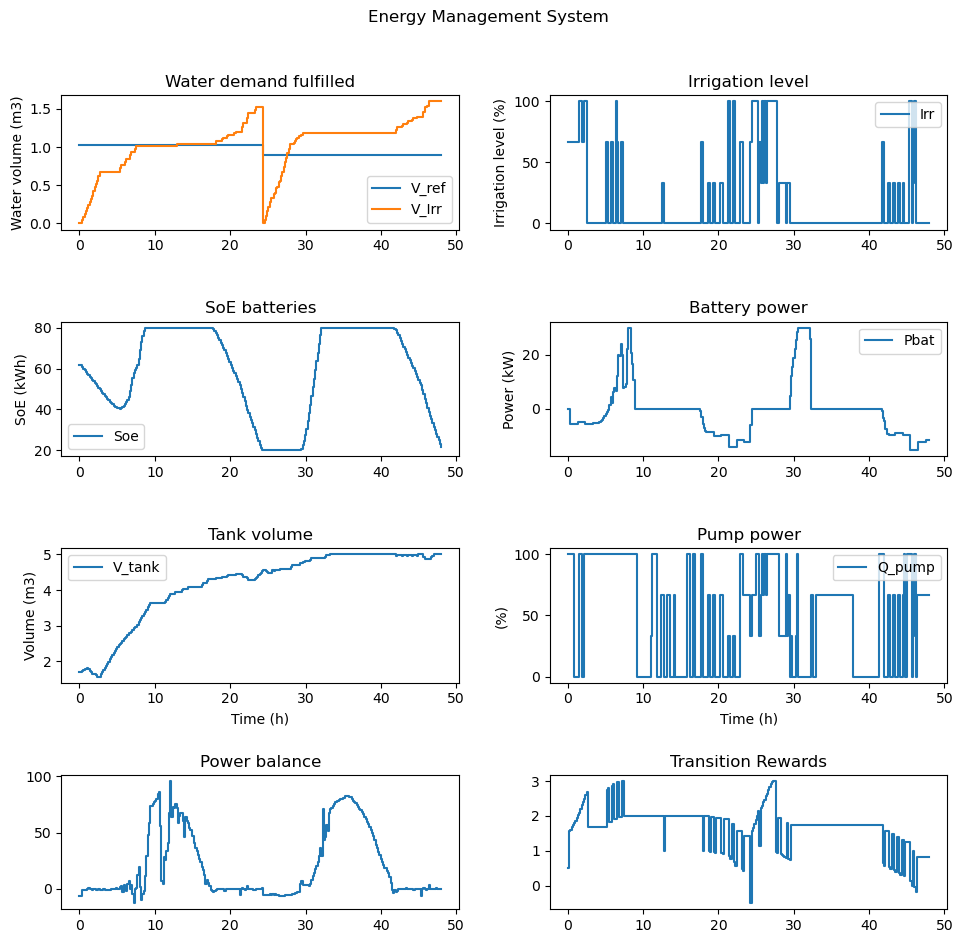

In [11]:
model = torch.load(path + '/policy.pt')
mdl = EMS_env()
mdl.show_sample(model)

In [18]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

gridx, gridy = np.meshgrid(a, b)

np.stack((gridx, gridy), axis=2).reshape(-1, 2)

array([[1, 4],
       [2, 4],
       [3, 4],
       [1, 5],
       [2, 5],
       [3, 5],
       [1, 6],
       [2, 6],
       [3, 6]])

In [21]:
import ipiopt

ModuleNotFoundError: No module named 'ipiopt'